In [2]:
# import pickle
import os
from os.path import join
import pandas as pd
import numpy as np
from datetime import datetime
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import zscore
from tqdm import tqdm

In [3]:
import importlib

import dataset
importlib.reload(dataset)

from dataset import TrialNumpyToDataframe
import processing 

In [4]:
base_dir = os.getcwd()
print(base_dir)

paths = {
    'compressed': join(base_dir, 'data', 'compressed'),
    'processed': join(base_dir, 'data', 'processed'),
    'results': join(base_dir, 'results')
}

/home/closedai/cronos/article/FCMH-dataset


In [ ]:
## Command used to compresss file npz
## 7z -v100m a fan-coil-forward-rear.7z processed/

In [ ]:
# on terminal (Ubuntu)
# !7z x 7z/fan-coil-forward-rear.7z.001

# Load FAN-COIL Dataset (npz)

In [8]:
file_name = 'fan-coil-foward-rear.npz'

data_dict = np.load(join(paths['processed'], file_name))

print(list(data_dict.keys()))

['foward', 'rear', 'timestamp', 'metric_foward', 'metric_rear', 'metric_columns']


In [9]:
foward_data = data_dict['foward']
rear_data = data_dict['rear']
timestamp = data_dict['timestamp']

print(foward_data.shape, rear_data.shape, timestamp.shape)

(5246, 320000) (5246, 320000) (5246,)


In [12]:
def plot(data, title='', figsize=(10, 3), MAX_INSTANCES=10):

    plt.figure(figsize=figsize)
    plt.plot(data[0:MAX_INSTANCES, :].flatten())
    # plt.ylim(-1, 1)
    plt.title(title)


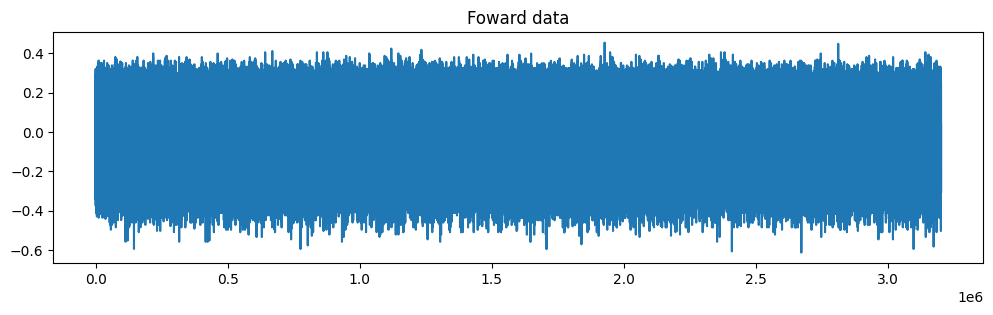

In [14]:
plot(data=foward_data, title='Foward data', figsize=(12, 3), MAX_INSTANCES=10)

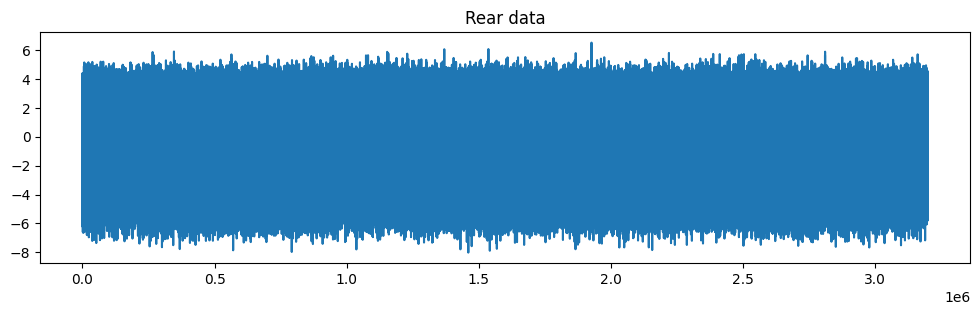

In [16]:
plot(data=rear_data, title='Rear data', figsize=(12, 3), MAX_INSTANCES=10)

## Get Metrics

In [17]:
def get_metrics(data, axis=0):

    metrics_dict = {
        'Mean': np.mean(data, axis=axis),
        'Std. Dev.': np.std(data, axis=axis),
        'Min.': np.min(data, axis=axis),
        '25%': np.percentile(data, 25, axis=axis),
        '50%': np.median(data, axis=axis),
        '75%': np.percentile(data, 75, axis=axis),
        'Max.': np.max(data, axis=axis),
    }

    return metrics_dict

In [18]:
# Foward Metrics
metrics_foward = get_metrics(data=foward_data.flatten(), axis=0)
metrics_foward

{'Mean': -4.30271e-08,
 'Std. Dev.': 0.17894623,
 'Min.': -14.670534,
 '25%': -0.08895492553710938,
 '50%': 0.004544258,
 '75%': 0.09245777130126953,
 'Max.': 7.3502235}

In [19]:
# Rear Metrics
metrics_rear = get_metrics(data=rear_data.flatten(), axis=0)
metrics_rear

{'Mean': 3.6558079e-06,
 'Std. Dev.': 1.4452503,
 'Min.': -14.72572,
 '25%': -0.8597621917724609,
 '50%': 0.000541687,
 '75%': 0.9140996932983398,
 'Max.': 10.305142}

In [29]:
pd.DataFrame.from_dict(metrics_foward, orient='index', columns=['values']).to_csv(join(paths['results'], 'summary_metrics_foward.csv'))
pd.DataFrame.from_dict(metrics_rear, orient='index', columns=['values']).to_csv(join(paths['results'], 'summary_metrics_rear.csv'))

# save metrics
# df_metrics_foward.to_csv(join(paths['results'], 'metrics_foward.csv') , index=False)
# df_metrics_rear.to_csv(join(paths['results'],'metrics_rear.csv'), index=False)

## Convert to RMS

In [30]:
def convert_acceleration_to_velocity(acceleration, sampling_rate):
    # Integrate acceleration to get velocity (using cumulative sum)
    velocity = np.cumsum(acceleration, axis=1) / sampling_rate
    
    # Convert from m/s to mm/s
    velocity_mm_s = velocity * 1000
    
    return velocity_mm_s

def calculate_rms_velocity(velocity):
    # Calculate RMS velocity for each instance
    rms_velocity = np.sqrt(np.mean(velocity ** 2, axis=1))
    
    return rms_velocity

def plot_rms_velocity(df, figsize=(12, 6), path_save=None):
    start_time = df['timestamp'].iloc[0]
    end_time = df['timestamp'].iloc[0]

    good_health = 2.8
    warning_health = 5.6
    bad_health = 8.9
    sns.set(style="whitegrid")
    plt.figure(figsize=figsize)
    sns.lineplot(data=df, x='timestamp', y='rms')
    plt.axhline(y=good_health, color='green', linestyle='--', label='Good Health (2.8 mm/s)')
    plt.axhline(y=warning_health, color='yellow', linestyle='--', label='Warning Health (5.6 mm/s)')
    plt.axhline(y=bad_health, color='red', linestyle='--', label='Bad Health (8.9 mm/s)')


    # plt.xlabel('Timestamp')
    plt.ylabel('RMS Velocity (mm/s)')
    # plt.title('RMS Velocity over Time')
    plt.xticks(rotation=45)
    if path_save is not None:
        plt.savefig(f'{path_save}.pdf', format='pdf', dpi=64, bbox_inches='tight')
    plt.tight_layout()
    plt.show()

## Foward

In [31]:
sampling_rate = 32000  # Sample rate in Hz

# Convert acceleration to velocity
velocity_mms_foward = convert_acceleration_to_velocity(
    acceleration=foward_data, 
    sampling_rate=sampling_rate
    )

# Calculate RMS velocity for each instance
rms_velocity_foward = calculate_rms_velocity(velocity_mms_foward)

print(velocity_mms_foward.shape, rms_velocity_foward.shape)

(5246, 320000) (5246,)


In [32]:
df_foward = pd.DataFrame(rms_velocity_foward, columns=['rms'])
df_foward['timestamp'] = timestamp
df_foward

,rms,timestamp
0,4.921060,2024-02-23 01:01:18.270
1,4.872216,2024-02-23 01:03:28.099
2,4.681833,2024-02-23 01:05:37.650
3,4.962951,2024-02-23 01:07:47.405
4,6.091011,2024-02-23 01:09:57.481
...,...,...
5241,4.206057,2024-03-12 14:12:00.328
5242,3.409338,2024-03-12 14:14:11.837
5243,3.010628,2024-03-12 14:18:29.553
5244,5.169856,2024-03-12 14:20:39.974


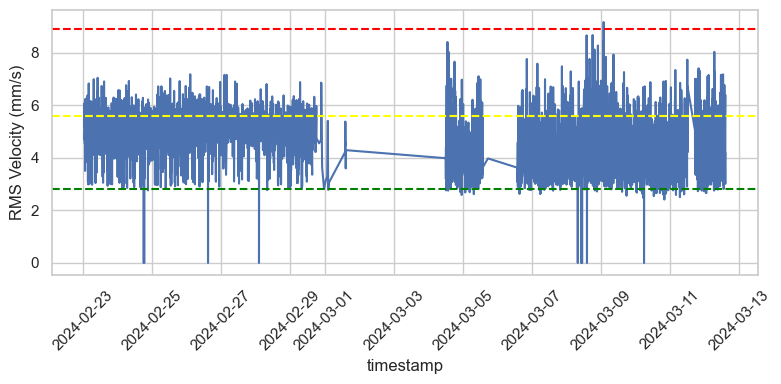

In [33]:
plot_rms_velocity(
    df_foward, 
    figsize=(8, 4), 
    # path_save='rms_foward'
    path_save=None
    )

In [25]:
df_foward.to_csv('rms_velocity_foward.csv', index=False)

## Rear

In [34]:
sampling_rate = 32000  # Sample rate in Hz

# Convert acceleration to velocity
velocity_mms_rear = convert_acceleration_to_velocity(
    acceleration=rear_data, 
    sampling_rate=sampling_rate
    )

# Calculate RMS velocity for each instance
rms_velocity_rear = calculate_rms_velocity(velocity_mms_rear)

In [35]:
df_rear = pd.DataFrame(rms_velocity_rear, columns=['rms'])
df_rear['timestamp'] = timestamp
df_rear

,rms,timestamp
0,9.590925,2024-02-23 01:01:18.270
1,14.477077,2024-02-23 01:03:28.099
2,7.884907,2024-02-23 01:05:37.650
3,10.147917,2024-02-23 01:07:47.405
4,14.021358,2024-02-23 01:09:57.481
...,...,...
5241,9.953805,2024-03-12 14:12:00.328
5242,9.655512,2024-03-12 14:14:11.837
5243,12.590260,2024-03-12 14:18:29.553
5244,6.210472,2024-03-12 14:20:39.974


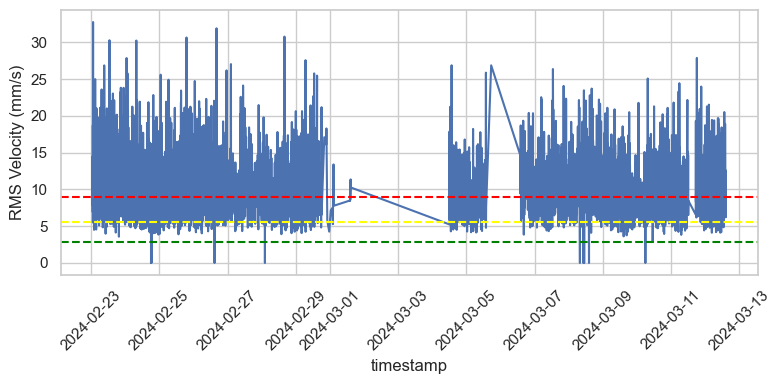

In [36]:
plot_rms_velocity(
    df_rear, 
    figsize=(8, 4), 
    # path_save='rms_rear'
    path_save=None
    )

In [28]:
df_rear.to_csv('rms_velocity_rear.csv', index=False)